In [23]:
# 관련 모듈과 라이브러리 import하기

# nn: 신경망 만들 때 쓰는 기본 도구들 (레이어, 활성화 함수 등)
import torch.nn as nn

# torch: 텐서 다루고 GPU 쓸 수 있게 해준다
import torch 

# datasets: 유명한 데이터셋 쉽게 다운받게 해줌
from torchvision import datasets

# transforms: 이미지를 모델이 먹을 수 있게 변환해줌(텐서로 변환하고 정규화)
from torchvision import transforms

# DataLoader: 데이터를 불러오는 애
from torch.utils.data import DataLoader

# numpy: 숫자 계산할 때 쓰는 라이브러리
import numpy as np

# optim: 모델을 학습시키는 최적화 알고리즘들 (경사하강법 등)
import torch.optim as optim 

# plt: 그래프 그리고 이미지 보여주는 애
import matplotlib.pyplot as plt

# 모델 불러오기
from models import CNN

# 공격 기법 불러오기
from attacks import fgsm_attack, ifgsm_attack, pgd_attack

In [24]:
# gpu 사용 위해 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [25]:
# 불러올 모델과 같은 구조를 정의하기
model = CNN()
# 저장해두었던 가중치, bias 불러오기 
model.load_state_dict(torch.load('cifar10_cnn_model.pth'))
# gpu로 모델 옮기기 
model.to(device)
# 평가 모드로 전환
# 레이어 동작이 학습할 때랑 다르게 바뀜 (예: Dropout, BatchNorm)
# Dropout: 학습할 때는 일부 뉴런 끄지만, 평가할 때는 모두 사용
# BatchNorm: 학습할 때는 미니배치 통계 사용하지만, 평가할 때는 전체 데이터셋 통계 사용한다!
model.eval()

/tmp/ipykernel_545295/4197865864.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('cifar10_cnn_model.pth'))


CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=10, bias=True)
  (relu): ReLU()
)

In [26]:
# 테스트 데이터셋 불러오자.

# 데이터셋 저장 경로
download_root = 'CIFAR10_data/'

#정규화 
transformations = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
# 테스트용 데이터셋
dataset2 = datasets.CIFAR10(root=download_root,
                            # 학습용이 아니므로 이번에는 False!
                            train = False, 
                            transform = transformations,
                            download=False)

In [27]:
# 공격 대상 데이터로더 만들기
test_loader = DataLoader(dataset2,
                        batch_size=100,
                        shuffle=False)

# 클래스 이름들
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

In [28]:
# 이미지 한 배치 가져오기
for images, labels in test_loader:
    # 배치에서 이미지와 레이블 가져오기
    images, labels = images.to(device), labels.to(device)
    # 원본 이미지로 모델 예측해보기
    break # 첫 번째 배치만 사용하기 위해 루프 종료 -> 이미지 64장과 레이블 64개만 있음

In [29]:
i = iter(test_loader)
print(next(i)[0][0].shape)

torch.Size([3, 32, 32])


In [30]:
print(images)
print(labels[0].shape)

tensor([[[[ 0.2392,  0.2471,  0.2941,  ...,  0.0745, -0.0118, -0.0902],
          [ 0.1922,  0.1843,  0.2471,  ...,  0.0667, -0.0196, -0.0667],
          [ 0.1843,  0.1843,  0.2392,  ...,  0.0902,  0.0196, -0.0588],
          ...,
          [-0.4667, -0.6706, -0.7569,  ..., -0.7020, -0.8980, -0.6863],
          [-0.5216, -0.6157, -0.7255,  ..., -0.7961, -0.7725, -0.8431],
          [-0.5765, -0.5608, -0.6471,  ..., -0.8118, -0.7333, -0.8353]],

         [[-0.1216, -0.1294, -0.0902,  ..., -0.2549, -0.2863, -0.3333],
          [-0.1216, -0.1373, -0.1059,  ..., -0.2549, -0.2863, -0.3098],
          [-0.1373, -0.1451, -0.1294,  ..., -0.2314, -0.2549, -0.3020],
          ...,
          [-0.0275, -0.2157, -0.3098,  ..., -0.2392, -0.4980, -0.3333],
          [-0.0902, -0.2000, -0.3333,  ..., -0.3569, -0.3569, -0.4980],
          [-0.1608, -0.1765, -0.3020,  ..., -0.3961, -0.3412, -0.4745]],

         [[-0.6157, -0.6314, -0.6000,  ..., -0.7176, -0.7176, -0.7412],
          [-0.6000, -0.6863, -

In [ ]:
# 공격 적용
epsilon = 0.1  # 공격 강도 설정
attack_success = 0
attack_fail = 0
success_cases = []  # 성공한 케이스 저장 (원본 이미지, 공격 이미지, 실제 레이블, 예측 레이블)
fail_cases = []     # 실패한 케이스 저장 (원본 이미지, 공격 이미지, 실제 레이블, 예측 레이블)

for image, label in zip(images, labels):
    # 해당 이미지에 대한 gradeint 계산
    # 이미지에 대한 gradient 계산을 위해 requires_grad 설정
    image.requires_grad = True
    # 모델 출력 계산
    output = model(image)
    loss_function = nn.CrossEntropyLoss()

    # 배치 차원 추가
    label = label.unsqueeze(0)  # [] → [1]

    # loss 계산
    loss = loss_function(output, label)
    #∂Loss/∂image 계산
    loss.backward()
    data_grad = image.grad.data

    # fgsm 공격 수행
    adv_image = fgsm_attack(image, epsilon, data_grad)
    adv_image = pgd_attack(model, image, label, epsilon, iters=10)
    # 공격된 이미지로 모델 예측해보기
    output = model(adv_image) #[1, 10]
    _, predicted = torch.max(output.data, 1)
    
    true_label = label.item()
    pred_label = predicted.item()
    
    if pred_label == true_label:
        # 공격 실패 (여전히 올바르게 분류)
        attack_fail += 1
        if len(fail_cases) < 5:
            fail_cases.append((image.detach().cpu(), adv_image.detach().cpu(), 
                             classes[true_label], classes[pred_label]))
    else:
        # 공격 성공 (잘못 분류됨)
        attack_success += 1
        if len(success_cases) < 5:
            success_cases.append((image.detach().cpu(), adv_image.detach().cpu(), 
                                classes[true_label], classes[pred_label]))

print("=== 공격 결과 요약 ===")
print(f'Attack Success Rate: {attack_success / (attack_success + attack_fail) * 100:.2f}%')
print()


=== 공격 결과 요약 ===
Attack Success Rate: 77.00%



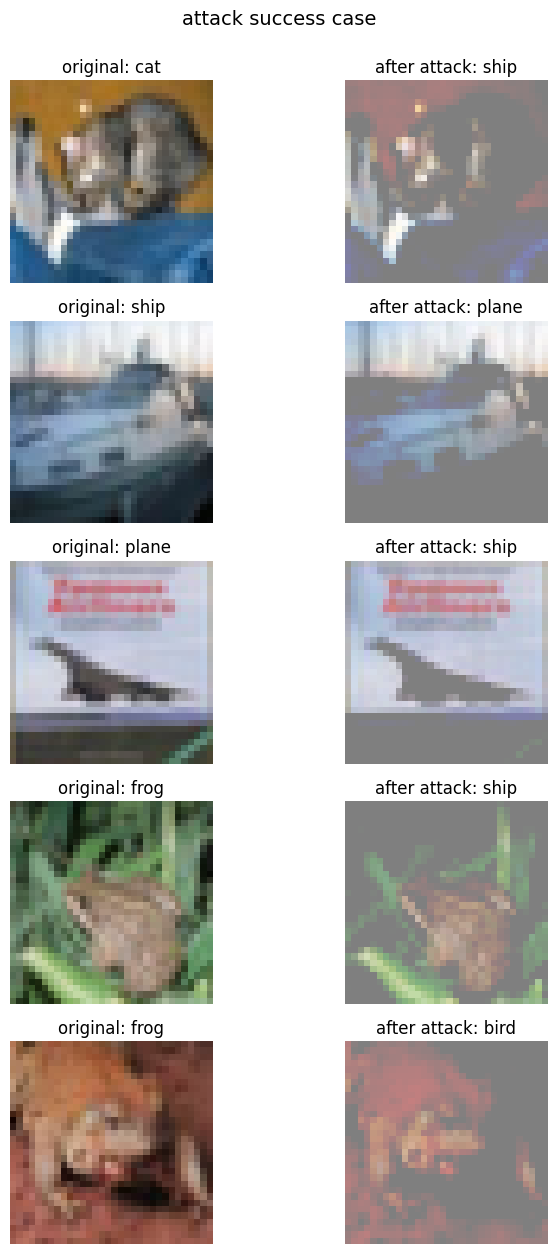

In [32]:
# 이미지를 denormalize하는 함수
def denormalize(img):
    """정규화된 이미지를 원래대로 되돌림"""
    img = img * 0.5 + 0.5  # [-1, 1] → [0, 1]
    return img

# 공격 성공 케이스 시각화
if len(success_cases) > 0:
    fig, axes = plt.subplots(len(success_cases), 2, figsize=(8, 2.5*len(success_cases)))
    if len(success_cases) == 1:
        axes = axes.reshape(1, -1)
    
    for i, (orig_img, adv_img, true_cls, pred_cls) in enumerate(success_cases):
        # 원본 이미지
        orig_np = denormalize(orig_img).squeeze().permute(1, 2, 0).numpy()
        axes[i, 0].imshow(orig_np)
        axes[i, 0].set_title(f'original: {true_cls}')
        axes[i, 0].axis('off')
        
        # 공격된 이미지
        adv_np = denormalize(adv_img).squeeze().permute(1, 2, 0).numpy()
        axes[i, 1].imshow(adv_np)
        axes[i, 1].set_title(f'after attack: {pred_cls}')
        axes[i, 1].axis('off')
    
    plt.suptitle('attack success case', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()


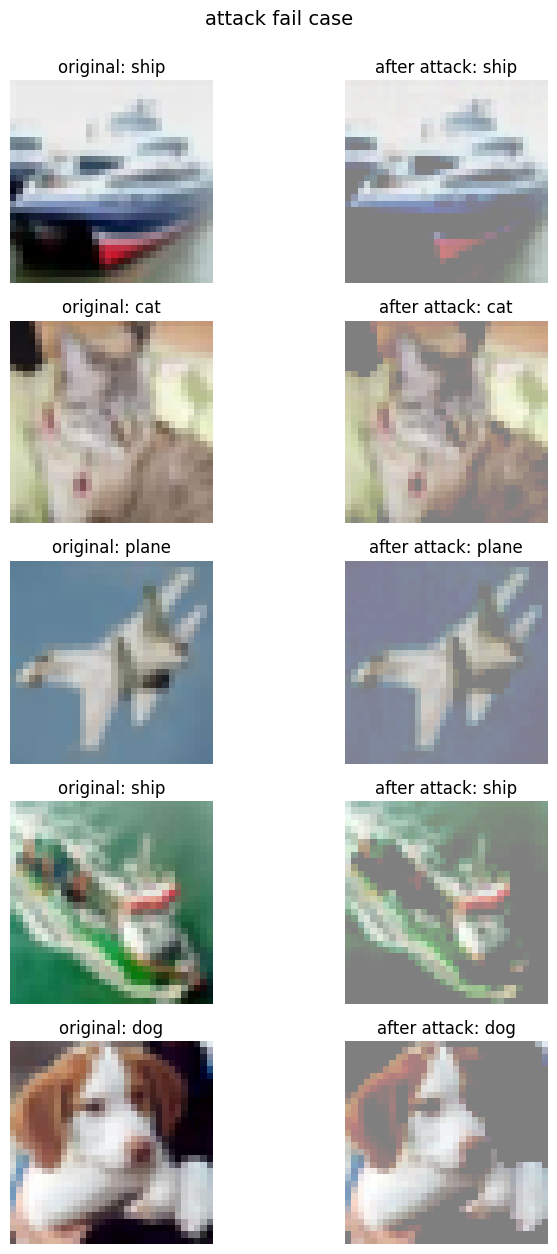

In [33]:
# 공격 실패 케이스 시각화
if len(fail_cases) > 0:
    fig, axes = plt.subplots(len(fail_cases), 2, figsize=(8, 2.5*len(fail_cases)))
    if len(fail_cases) == 1:
        axes = axes.reshape(1, -1)
    
    for i, (orig_img, adv_img, true_cls, pred_cls) in enumerate(fail_cases):
        # 원본 이미지
        orig_np = denormalize(orig_img).squeeze().permute(1, 2, 0).numpy()
        axes[i, 0].imshow(orig_np)
        axes[i, 0].set_title(f'original: {true_cls}')
        axes[i, 0].axis('off')
        
        # 공격된 이미지
        adv_np = denormalize(adv_img).squeeze().permute(1, 2, 0).numpy()
        axes[i, 1].imshow(adv_np)
        axes[i, 1].set_title(f'after attack: {pred_cls}')
        axes[i, 1].axis('off')
    
    plt.suptitle('attack fail case', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()
